In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv("Arrest_Data_From_2010_to_2019.csv")

In [3]:
data.head()

,Report ID,Arrest Date,Time,Area ID,Area Name,Reporting District,Age,Sex Code,Descent Code,Charge Group Code,Charge Group Description,Arrest Type Code,Charge,Charge Description,Address,Cross Street,Location
0,191811472,05/03/2019,1700.0,18,Southeast,1802,23,F,B,NaN,NaN,M,653.22 PC,NaN,91ST,FIGUEROA,"(33.9543, -118.2827)"
1,5614161,04/29/2019,1040.0,8,West LA,842,41,M,H,3.0,Robbery,F,211PC,ROBBERY,11600 WILSHIRE BL,NaN,"(34.0508, -118.4592)"
2,5615197,04/30/2019,615.0,6,Hollywood,663,27,M,O,5.0,Burglary,F,459PC,BURGLARY,LA BREA,LEXINGTON,"(34.0907, -118.3384)"
3,5615701,04/30/2019,1100.0,9,Van Nuys,901,2,F,H,NaN,NaN,D,300(B)WIC,NaN,RAYMER,SEPULVEDA BL,"(34.2149, -118.4674)"
4,5615929,04/30/2019,1550.0,20,Olympic,2049,41,M,W,4.0,Aggravated Assault,F,245(A)(2)PC,ADW W/FIREARM,8TH ST,VERMONT,"(34.0578, -118.2916)"


1. How many 2018 arrests.

In [4]:
#chec the type
type(data["Arrest Date"].iloc[0])

str

In [5]:
# well conver it
data["Arrest Date"] = pd.to_datetime(data["Arrest Date"], format="%m/%d/%Y")
num_2018 = (data["Arrest Date"].dt.year == 2018).sum()
print(num_2018)

104277


2. How many bookings of arrestees were made in the area with the most arrests in
2018?

In [6]:
# take the 2018 dataframe, find how many are in each location, top should be largest
data_2018 = data[data["Arrest Date"].dt.year == 2018]
data_2018["Area Name"].value_counts()

Area Name
Central        10951
Hollywood       9715
Rampart         7345
Pacific         6778
77th Street     6259
Van Nuys        6193
Southwest       5927
Newton          5427
N Hollywood     4947
Mission         4357
Olympic         3898
Harbor          3875
Southeast       3601
Hollenbeck      3590
West Valley     3562
Northeast       3452
Devonshire      3146
Topanga         3094
Foothill        3006
West LA         2687
Wilshire        2467
Name: count, dtype: int64

SO it must be the largest, so Central at 10951.

3. What is the 95% quantile of the age of the arrestee in 2018? Only consider the following charge groups for your analysis: Vehicle Theft, Robbery, Burglary, Receive Stolen Property.

In [7]:
# so lets go through and ensure that we only have the charge groups we want
# first lets see the options
data_2018["Charge Group Description"].value_counts()

Charge Group Description
Miscellaneous Other Violations    17023
Narcotic Drug Laws                10697
Aggravated Assault                 9231
Driving Under Influence            8918
Other Assaults                     7907
Larceny                            5129
Drunkeness                         3769
Moving Traffic Violations          3565
Liquor Laws                        3481
Weapon (carry/poss)                3396
Vehicle Theft                      3257
Prostitution/Allied                2970
Robbery                            2787
Disorderly Conduct                 2536
Burglary                           1958
Sex (except rape/prst)             1179
Fraud/Embezzlement                 1061
Against Family/Child                923
Receive Stolen Property             455
Forgery/Counterfeit                 415
Rape                                315
Homicide                            274
Non-Criminal Detention              198
Gambling                            175
Disturbing the 

In [8]:
# Looks right, lets sort now
charges_to_keep = ["Robbery", "Vehicle Theft", "Burglary", "Receive Stolen Property"]
data_2018_filtered = data_2018[data_2018["Charge Group Description"].isin(charges_to_keep)]
data_2018_filtered["Charge Group Description"].value_counts()

Charge Group Description
Vehicle Theft              3257
Robbery                    2787
Burglary                   1958
Receive Stolen Property     455
Name: count, dtype: int64

In [9]:
#looks like we've correctly kept all of them - lets make sure its an integer
type(data_2018_filtered["Age"].iloc[0])

numpy.int64

In [10]:
data_2018_filtered["Age"].quantile(q=0.95)

52.0

4. There are differences between the average age of an arrestee for the various charge groups. Are these differences statistically significant? For this question, calculate the Z-score of the average age for each charge group. Report the largest absolute value among the calculated Z-scores. (Only consider data for 2018. Do not consider "Pre-Delinquency" and "Non-Criminal Detention" as these charge groups are reserved for minors. Exclude any arrests where the charge group description is not known.)

In [11]:
from scipy.stats import zscore
# keey everything not in Pre-Delinquency or non criminal detention, and of course not NA
data_2018_ex_minor = data_2018[(~data_2018['Charge Group Description'].isin(['Pre-Delinquency', 'Non-Criminal Detention'])) &
    (data_2018['Charge Group Description'].notna())]
# find average for every group
group_avg_age = data_2018_ex_minor.groupby('Charge Group Description')['Age'].mean()
#just to check
group_avg_age

Charge Group Description
Against Family/Child              35.539545
Aggravated Assault                34.434622
Burglary                          30.391216
Disorderly Conduct                41.229890
Disturbing the Peace              39.010204
Driving Under Influence           34.953353
Drunkeness                        43.905015
Federal Offenses                  34.080000
Forgery/Counterfeit               34.265060
Fraud/Embezzlement                35.615457
Gambling                          41.308571
Homicide                          30.470803
Larceny                           33.776565
Liquor Laws                       42.483482
Miscellaneous Other Violations    35.537684
Moving Traffic Violations         33.874614
Narcotic Drug Laws                36.303356
Other Assaults                    34.091311
Prostitution/Allied               30.006061
Rape                              35.168254
Receive Stolen Property           31.791209
Robbery                           27.182992
Sex (ex

In [12]:
z_scores = zscore(group_avg_age)
z_scores

Charge Group Description
Against Family/Child              0.154733
Aggravated Assault               -0.111677
Burglary                         -1.086590
Disorderly Conduct                1.526744
Disturbing the Peace              0.991551
Driving Under Influence           0.013396
Drunkeness                        2.171748
Federal Offenses                 -0.197180
Forgery/Counterfeit              -0.152560
Fraud/Embezzlement                0.173037
Gambling                          1.545715
Homicide                         -1.067401
Larceny                          -0.270342
Liquor Laws                       1.829000
Miscellaneous Other Violations    0.154285
Moving Traffic Violations        -0.246701
Narcotic Drug Laws                0.338897
Other Assaults                   -0.194453
Prostitution/Allied              -1.179456
Rape                              0.065211
Receive Stolen Property          -0.749035
Robbery                          -1.860131
Sex (except rape/prst)       

In [13]:
# I thought it might be ordered, but it seems it isn't
# we can just apply abs then use max
abs(z_scores).max()

2.1717481576567237

5. How many arrest incidents occurred within 2 km from the Bradbury Building(https://en.wikipedia.org/wiki/Bradbury_Building ) in 2018? [Use (34.050536, -118.247861) for the coordinates of the Bradbury Building. For simplicity, please use the spherical Earth projected to a plane(https://en.wikipedia.org/wiki/Geographical_distance#Spherical_Earth_projected_) equation for calculating distances. Use the radius of the Earth as 6371 km. Note, some arrest records are missing location data and the location is listed as (0, 0). These records should not factor in your calculation.]

In [14]:
#lets see how 0,0 is represented
print(type(data_2018["Location"].iloc[0]))
print(len(data_2018[(data_2018["Location"] == '(0,0)')]))
print(data_2018['Location'].unique()[:5])

<class 'str'>
0
['(34.0949, -118.3109)' '(34.0574, -118.3547)' '(34.0219, -118.3061)'
 '(33.998, -118.2543)' '(33.9392, -118.2739)']


In [15]:
# we'll ignore na data
data_2018_clean = data_2018[data_2018["Location"].notna() & (data_2018["Location"] != '(0, 0)')]
data_2018_clean.head()

,Report ID,Arrest Date,Time,Area ID,Area Name,Reporting District,Age,Sex Code,Descent Code,Charge Group Code,Charge Group Description,Arrest Type Code,Charge,Charge Description,Address,Cross Street,Location
156,5213460,2018-01-24,1930.0,6,Hollywood,668,29,M,H,10.0,Fraud/Embezzlement,F,530.5(A)PC,GET CREDIT/ETC OTHER'S ID,ST ANDREWS,FOUNTAIN,"(34.0949, -118.3109)"
157,5257944,2018-03-15,310.0,7,Wilshire,743,33,F,O,1.0,Homicide,F,191.5(B)PC,VEH MANSLAUGHTR/OPER VESSEL DUI & DUR FEL,OLYMPIC,MASSELIN,"(34.0574, -118.3547)"
158,5328813,2018-06-01,1800.0,3,Southwest,356,44,F,B,16.0,Narcotic Drug Laws,F,11379(A)HS,TRANSPORT/SELL CONTROLLED SUBSTANCE,1600 W 36TH PL,NaN,"(34.0219, -118.3061)"
159,5336331,2018-06-10,200.0,13,Newton,1364,23,M,H,12.0,Weapon (carry/poss),F,25400(A)2PC,CARRYING CONCEALED WEAPON UPON PERSON,1200 E 50TH ST,NaN,"(33.998, -118.2543)"
160,5360731,2018-07-07,2330.0,18,Southeast,1832,32,M,B,12.0,Weapon (carry/poss),F,29800(A)1PC,POSS F/ARM BY CONVICTED FELON/ADDICT/ETC,10700 S MAIN ST,NaN,"(33.9392, -118.2739)"


In [16]:
# I;ll also try to parse it since we know its a string
def CoordParser(coord):
    # smth like "(34.0949, -118.3109)"
    split_coord = coord[1:-1].split(", ")
    lat = float(split_coord[0])
    long = float(split_coord[1])
    return np.radians([lat, long])

data_2018_clean["Location"] = data_2018_clean["Location"].apply(CoordParser)
data_2018_clean.head()

,Report ID,Arrest Date,Time,Area ID,Area Name,Reporting District,Age,Sex Code,Descent Code,Charge Group Code,Charge Group Description,Arrest Type Code,Charge,Charge Description,Address,Cross Street,Location
156,5213460,2018-01-24,1930.0,6,Hollywood,668,29,M,H,10.0,Fraud/Embezzlement,F,530.5(A)PC,GET CREDIT/ETC OTHER'S ID,ST ANDREWS,FOUNTAIN,"[0.5950682631382147, -2.0649147459977595]"
157,5257944,2018-03-15,310.0,7,Wilshire,743,33,F,O,1.0,Homicide,F,191.5(B)PC,VEH MANSLAUGHTR/OPER VESSEL DUI & DUR FEL,OLYMPIC,MASSELIN,"[0.5944137646687168, -2.0656792002101327]"
158,5328813,2018-06-01,1800.0,3,Southwest,356,44,F,B,16.0,Narcotic Drug Laws,F,11379(A)HS,TRANSPORT/SELL CONTROLLED SUBSTANCE,1600 W 36TH PL,NaN,"[0.5937941727842588, -2.0648309701936634]"
159,5336331,2018-06-10,200.0,13,Newton,1364,23,M,H,12.0,Weapon (carry/poss),F,25400(A)2PC,CARRYING CONCEALED WEAPON UPON PERSON,1200 E 50TH ST,NaN,"[0.5933770390930321, -2.0639268896411305]"
160,5360731,2018-07-07,2330.0,18,Southeast,1832,32,M,B,12.0,Weapon (carry/poss),F,29800(A)1PC,POSS F/ARM BY CONVICTED FELON/ADDICT/ETC,10700 S MAIN ST,NaN,"[0.5923507854928595, -2.0642689741745213]"


In [17]:
# 6371km radius, can use the formula -> 
brad_lat, brad_long = np.radians([34.050536, -118.247861])
rad = 6371

def distanceFromBrad(Coord):
    # should be [lat, long] in radians
    delta_lat = Coord[0] - brad_lat
    delta_lon = Coord[1] - brad_long
    avg_lat = (Coord[0] + brad_lat) / 2

    # using the non-approximation one 
    # unsure if it counts as 'medium or low latitude' as specified in the wikipedia site
    # so i'll use the full one
    term1 = (delta_lat * np.cos(delta_lon / 2))**2
    term2 = (2 * np.cos(avg_lat) * np.sin(delta_lon / 2))**2
    return rad * np.sqrt(term1 + term2)
    

data_2018_clean["Dist. From Bradbury"] = data_2018_clean["Location"].apply(distanceFromBrad)
data_2018_clean.head()

,Report ID,Arrest Date,Time,Area ID,Area Name,Reporting District,Age,Sex Code,Descent Code,Charge Group Code,Charge Group Description,Arrest Type Code,Charge,Charge Description,Address,Cross Street,Location,Dist. From Bradbury
156,5213460,2018-01-24,1930.0,6,Hollywood,668,29,M,H,10.0,Fraud/Embezzlement,F,530.5(A)PC,GET CREDIT/ETC OTHER'S ID,ST ANDREWS,FOUNTAIN,"[0.5950682631382147, -2.0649147459977595]",7.618898
157,5257944,2018-03-15,310.0,7,Wilshire,743,33,F,O,1.0,Homicide,F,191.5(B)PC,VEH MANSLAUGHTR/OPER VESSEL DUI & DUR FEL,OLYMPIC,MASSELIN,"[0.5944137646687168, -2.0656792002101327]",9.872214
158,5328813,2018-06-01,1800.0,3,Southwest,356,44,F,B,16.0,Narcotic Drug Laws,F,11379(A)HS,TRANSPORT/SELL CONTROLLED SUBSTANCE,1600 W 36TH PL,NaN,"[0.5937941727842588, -2.0648309701936634]",6.240021
159,5336331,2018-06-10,200.0,13,Newton,1364,23,M,H,12.0,Weapon (carry/poss),F,25400(A)2PC,CARRYING CONCEALED WEAPON UPON PERSON,1200 E 50TH ST,NaN,"[0.5933770390930321, -2.0639268896411305]",5.871799
160,5360731,2018-07-07,2330.0,18,Southeast,1832,32,M,B,12.0,Weapon (carry/poss),F,29800(A)1PC,POSS F/ARM BY CONVICTED FELON/ADDICT/ETC,10700 S MAIN ST,NaN,"[0.5923507854928595, -2.0642689741745213]",12.610589


In [18]:
data_2018_closest2 = data_2018_clean[(data_2018_clean["Dist. From Bradbury"] < 2)]
len(data_2018_closest2)

11461

6. How many arrest incidents were made per kilometer on Pico Boulevard during 2018? For this question, we will need to estimate the length of Pico Boulevard, which mostly stretches from east to west. To estimate the length of Pico Boulevard:

Consider all location data which the listed address mentions "Pico". Remove outliers by filtering out locations where either the latitude or longitude is 2 standard deviations beyond the mean of the subset of identified points. To estimate the length, calculate the distance from the most western and eastern coordinate points. As before, use the simplified flat surface equation.

Once you have estimated the length of Pico Boulevard, you can proceed to report the number of arrest incidents per kilometer on Pico Boulevard in 2018.

In [19]:
### get all addresses with pico excluding NA, and case insenstiive
data_2018_clean = data_2018_clean.drop(columns=["Dist. From Bradbury"])
data_2018_pico = data_2018_clean[data_2018_clean["Address"].str.contains('pico', case=False, na=False)]
data_2018_pico.head()

,Report ID,Arrest Date,Time,Area ID,Area Name,Reporting District,Age,Sex Code,Descent Code,Charge Group Code,Charge Group Description,Arrest Type Code,Charge,Charge Description,Address,Cross Street,Location
186,5485873,2018-12-01,1350.0,20,Olympic,2076,37,M,B,8.0,Other Assaults,M,243(B)PC,BATTERY ON PO/EMERGENCY PERSONNEL W/O INJ,PICO BL,BERENDO ST,"[0.5942374864142653, -2.0646128040371643]"
4739,5270090,2018-03-29,931.0,8,West LA,836,53,M,W,6.0,Larceny,F,487(A)PC,GRAND THEFT MONEY/PROPERTY > $400,PICO BL,PROSSER ST,"[0.594326498206117, -2.066902676015781]"
6681,182016070,2018-08-08,1350.0,20,Olympic,2071,28,M,H,18.0,Drunkeness,M,41.27CLAMC,DRINKING IN PUBLIC,PICO BL,WESTERN AV,"[0.5942357410850133, -2.0648815847419715]"
6754,5299360,2018-05-01,325.0,20,Olympic,2076,33,M,H,5.0,Burglary,F,459PC,BURGLARY,2500 W PICO BL,NaN,"[0.5942374864142653, -2.0645778974521245]"
6764,5405832,2018-08-27,415.0,7,Wilshire,753,22,M,H,8.0,Other Assaults,M,243(A)PC,BATTERY ON PERSON,PICO BL,FAIRFAX,"[0.594310790242849, -2.065888639720372]"


In [20]:
# lets split them apart, to make comparisons easier
# data_2018_pico['Latitude'] = data_2018_pico['Location'].apply(lambda loc: loc[0])
# data_2018_pico['Longitude'] = data_2018_pico['Location'].apply(lambda loc: loc[1])
data_2018_pico.loc[:, 'Latitude'] = data_2018_pico['Location'].apply(lambda loc: loc[0])
data_2018_pico.loc[:, 'Longitude'] = data_2018_pico['Location'].apply(lambda loc: loc[1])

lat_mean, lat_std = data_2018_pico['Latitude'].mean(), data_2018_pico['Latitude'].std()
lon_mean, lon_std = data_2018_pico['Longitude'].mean(), data_2018_pico['Longitude'].std()

/var/folders/xx/2vts4x1x02nb78rfhx41_drm0000gn/T/ipykernel_68033/134317647.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2018_pico.loc[:, 'Latitude'] = data_2018_pico['Location'].apply(lambda loc: loc[0])
/var/folders/xx/2vts4x1x02nb78rfhx41_drm0000gn/T/ipykernel_68033/134317647.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2018_pico.loc[:, 'Longitude'] = data_2018_pico['Location'].apply(lambda loc: loc[1])


In [21]:
mask = (
    (data_2018_pico['Latitude'] >= lat_mean - 2 * lat_std) & (data_2018_pico['Latitude'] <= lat_mean + 2 * lat_std) &
    (data_2018_pico['Longitude'] >= lon_mean - 2 * lon_std) & (data_2018_pico['Longitude'] <= lon_mean + 2 * lon_std)
)

pico_filtered = data_2018_pico[mask].copy()
pico_filtered.head()

,Report ID,Arrest Date,Time,Area ID,Area Name,Reporting District,Age,Sex Code,Descent Code,Charge Group Code,Charge Group Description,Arrest Type Code,Charge,Charge Description,Address,Cross Street,Location,Latitude,Longitude
186,5485873,2018-12-01,1350.0,20,Olympic,2076,37,M,B,8.0,Other Assaults,M,243(B)PC,BATTERY ON PO/EMERGENCY PERSONNEL W/O INJ,PICO BL,BERENDO ST,"[0.5942374864142653, -2.0646128040371643]",0.594237,-2.064613
4739,5270090,2018-03-29,931.0,8,West LA,836,53,M,W,6.0,Larceny,F,487(A)PC,GRAND THEFT MONEY/PROPERTY > $400,PICO BL,PROSSER ST,"[0.594326498206117, -2.066902676015781]",0.594326,-2.066903
6681,182016070,2018-08-08,1350.0,20,Olympic,2071,28,M,H,18.0,Drunkeness,M,41.27CLAMC,DRINKING IN PUBLIC,PICO BL,WESTERN AV,"[0.5942357410850133, -2.0648815847419715]",0.594236,-2.064882
6754,5299360,2018-05-01,325.0,20,Olympic,2076,33,M,H,5.0,Burglary,F,459PC,BURGLARY,2500 W PICO BL,NaN,"[0.5942374864142653, -2.0645778974521245]",0.594237,-2.064578
6764,5405832,2018-08-27,415.0,7,Wilshire,753,22,M,H,8.0,Other Assaults,M,243(A)PC,BATTERY ON PERSON,PICO BL,FAIRFAX,"[0.594310790242849, -2.065888639720372]",0.594311,-2.065889


In [22]:
west_point = pico_filtered.loc[pico_filtered['Longitude'].idxmin()]
east_point = pico_filtered.loc[pico_filtered['Longitude'].idxmax()]

In [23]:
lat_west, long_west = west_point["Latitude"], west_point["Longitude"]
lat_east, long_east = east_point["Latitude"], east_point["Longitude"]

# then reusing code from earliers calculation
delta_lat = lat_west - lat_east
delta_lon = long_west - long_east
avg_lat = (lat_west + lat_east) / 2

term1 = (delta_lat * np.cos(delta_lon / 2))**2
term2 = (2 * np.cos(avg_lat) * np.sin(delta_lon / 2))**2
dist = rad * np.sqrt(term1 + term2)
print(dist)

21.87541441885577


7. Some types of arrest incidents in certain areas occur at a highly disproportionate rate compared to their frequency city-wide. For example, let's say that the rate of larceny arrests (charge group code 6) is 1% in Devonshire (area ID 17). This rate may appear low but what if larceny arrests constitute 0.1 % city-wide? The ratio between these two probabilities is 10 and we can say that larceny occurs unusually often in Devonshire (Note, these numbers were made up for illustration purposes). Calculate this ratio for all charge group code and area ID pairs. You can view this ratio as the ratio of the conditional probability of an arrest incident of a charge group code given that it occurred in an area ID to the unconditional probability of the arrest incident of a charge group. Report the average of the top 5 of the calculated ratio.

Consider all records prior to January 1, 2019.
Some arrest incidents don't have a charge group code. These records should not be considered in your analysis. Arrest incidents for charge group code 99 should not be considered in your analysis.

In [24]:
# Basically just conditional probability of charge group given area vs cond. prob. of charge group overall
#all data before jan first is just anythoing with year before 2019
data_prior_2019 = data[data["Charge Group Code"].notna() & (data["Charge Group Code"] != 99) & (data["Arrest Date"].dt.year < 2019)]

# for every area, find every charge group percentage, compare to overall
arrests_count = len(data_prior_2019)
city_counts = data_prior_2019["Charge Group Code"].value_counts()
city_probs = city_counts / arrests_count

all_areas = data_prior_2019["Area Name"].unique()
all_charge_groups = data_prior_2019["Charge Group Code"].unique()

In [25]:
ratios = {}

# lets loop through all combinations
for area in all_areas:
    # filter by area
    area_data = data_prior_2019[data_prior_2019["Area Name"] == area]
    area_total = len(area_data)

    for charge_group in all_charge_groups:
        # count # of changes in that area
        charge_data = area_data[area_data["Charge Group Code"] == charge_group]
        charge_inarea_count = len(charge_data)

        prob_charge_inarea = charge_inarea_count / area_total

        if charge_group in city_probs:
            prob_overall = city_probs[charge_group]
        else:
            continue

        if prob_overall > 0:
            ratio = prob_charge_inarea / prob_overall
            ratios[(area, charge_group)] = ratio

sorted_values = sorted(ratios.values(), reverse=True)
top_5 = sorted_values[:5]
average_top5 = sum(top_5) / 5
print(average_top5)

3.515076379865202


8. Felony arrest incidents have been dropping over the years. Using a trend line (linear estimation) for the data from 2010 and 2018 (inclusive), what is the projected number of felony arrests in 2019? Round to the nearest integer. Note, the data set includes arrests for misdemeanor, felonies, etc.

In [26]:
# similar to before's filter, but we wont get rid of the other values
# no filter for fellony, so maybe i can look up which are fellonies?

data_until_2019 = data[(data["Arrest Date"].dt.year < 2019) & (data["Arrest Date"].dt.year >= 2010)]
data_until_2019["Charge Group Description"].value_counts()

Charge Group Description
Miscellaneous Other Violations    229826
Narcotic Drug Laws                153432
Drunkeness                        113420
Driving Under Influence           112996
Aggravated Assault                 77964
Larceny                            66257
Other Assaults                     56650
Moving Traffic Violations          50471
Liquor Laws                        49222
Prostitution/Allied                36780
Disorderly Conduct                 36264
Weapon (carry/poss)                28403
Robbery                            24415
Burglary                           22726
Vehicle Theft                      22723
Sex (except rape/prst)             12606
Pre-Delinquency                    11853
Fraud/Embezzlement                  8890
Non-Criminal Detention              6697
Forgery/Counterfeit                 6683
Against Family/Child                6501
Receive Stolen Property             6358
Disturbing the Peace                2878
Rape                            

In [27]:
fellonies = [
    'Homicide',
    'Rape',
    'Robbery',
    'Aggravated Assault',
    'Burglary',
    'Vehicle Theft',
    'Fraud/Embezzlement',
    'Forgery/Counterfeit',
    'Weapon (carry/poss)',
    'Narcotic Drug Laws',
    'Receive Stolen Property',
    'Sex (except rape/prst)',
    'Federal Offenses'
]
data_until_2019 = data_until_2019[data_until_2019["Charge Group Description"].isin(fellonies)]
data_until_2019["Year"] = data_until_2019["Arrest Date"].dt.year
data_until_2019 = data_until_2019.groupby(["Year"])
fellony_counts_byyear = data_until_2019.size()

<Axes: xlabel='Year', ylabel='Count'>

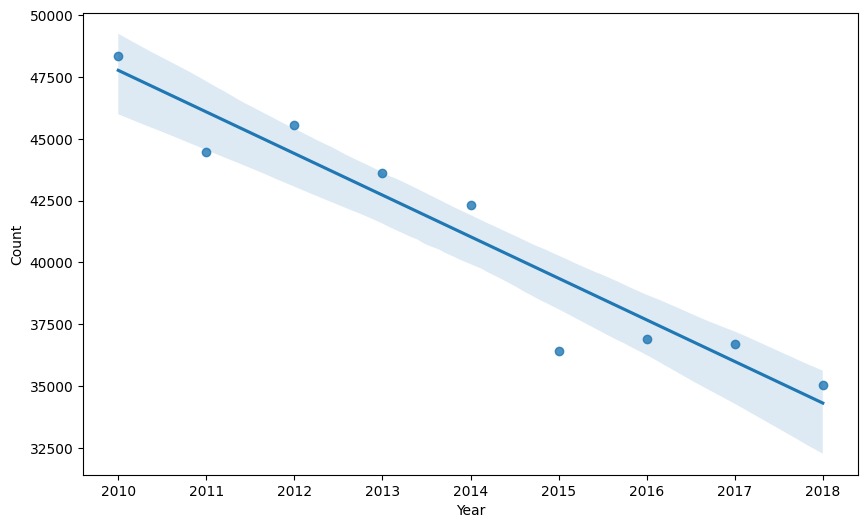

In [30]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

felony_df = fellony_counts_byyear.reset_index(name='Count')

plt.figure(figsize=(10, 6))
sns.regplot(x='Year', y='Count', data=felony_df)

In [33]:
X = felony_df['Year'].values.reshape(-1, 1)
y = felony_df['Count'].values
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict([[2019]])
print(y_pred)

[32634.25]
